# Spam Email Filter

### Create synthetic dataset

In [194]:
import pandas as pd
import numpy as np

# Examples of spam and ham emails
spam_examples = [
    "Free iPhone! Click here to claim your prize now. Limited time offer!",
    "Urgent: Your account has been suspended. Verify your details immediately to avoid deactivation.",
    "Congratulations, you've won a lottery you didn't enter! Send us your bank details to claim.",
    "Make money fast from home! Work only 2 hours a day and earn $5000 weekly. Click here.",
    "Your Netflix subscription is about to expire. Update your payment information here.",
    "Exclusive offer: Get 90% off on all products! Only for a few hours. Shop now!",
    "Dear customer, we detected unusual activity on your Amazon account. Please log in to review.",
    "Investment opportunity: High returns guaranteed with minimal risk. Contact us today!",
    "You have a new message from a secret admirer. Click to reveal who it is!",
    "Loan approved instantly! No credit check required. Apply here.",
    "Warning: Your computer is infected with viruses. Download our free software to clean it.",
    "Claim your tax refund now! Click the link and provide your personal information.",
    "Your order has been shipped. Track your package here for delivery details.",
    "Unclaimed funds detected in your name. Fill out this form to retrieve them.",
    "Limited stock! Buy 1 Get 1 Free on all electronics. Don't miss out!"
]

ham_examples = [
    "Hello, can we reschedule our meeting to next Tuesday?",
    "Please find the attached report for the Q3 results.",
    "Just confirming our lunch plans for tomorrow at 1 PM.",
    "Regarding your query about the project, I've sent a detailed response.",
    "Could you please review the document and provide your feedback by end of day?",
    "Reminder: The team stand-up is at 9 AM tomorrow.",
    "Thanks for the information, I'll look into it.",
    "Your package from Amazon has been delivered successfully.",
    "Wishing you a happy birthday! Hope you have a great day.",
    "Following up on our conversation from last week. Any updates?",
    "I've uploaded the files to the shared drive. Let me know if you have access.",
    "Don't forget to submit your timesheet by Friday.",
    "Here are the notes from our last brainstorming session.",
    "Is there anything else you need assistance with today?",
    "Good morning team, let's discuss the new proposal."
]

# Create synthetic dataset
def create_synthetic_data(examples, label):
    data = []
    for text in examples:
        data.append({'text': text, 'label': label})
    return data

# add label
expanded_spam_data = create_synthetic_data(spam_examples, 'spam')
expanded_ham_data = create_synthetic_data(ham_examples, 'ham')

# Combine and shuffle the data
combined_data = expanded_spam_data + expanded_ham_data
np.random.shuffle(combined_data)

df = pd.DataFrame(combined_data)

print(f"synthetic dataset shape: {df.shape}")
display(df.head())

synthetic dataset shape: (30, 2)


,text,label
0,Just confirming our lunch plans for tomorrow a...,ham
1,Unclaimed funds detected in your name. Fill ou...,spam
2,Investment opportunity: High returns guarantee...,spam
3,Following up on our conversation from last wee...,ham
4,Limited stock! Buy 1 Get 1 Free on all electro...,spam


## Text Preprocessing
1.  **Cleaning**: Lowercasing and removing punctuation.
2.  **Tokenization**: Splitting text into words.
3.  **Stopword Removal**: Eliminating common words.
4.  **Stemming**: Reducing words to their base form.
5.  **Vectorization**: Converting text into numerical features using TF-IDF.

In [195]:
# Import necessary libraries for text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Initialize stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-z]', ' ', text)
    # 3. Tokenize
    words = nltk.word_tokenize(text)
    # 4. Remove stopwords and apply stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    # Join back to a string
    return ' '.join(words)

# Apply preprocessing to the 'text' column
df['processed_text'] = df['text'].apply(preprocess_text)
display(df[['text', 'processed_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text,processed_text
0,Just confirming our lunch plans for tomorrow a...,confirm lunch plan tomorrow pm
1,Unclaimed funds detected in your name. Fill ou...,unclaim fund detect name fill form retriev
2,Investment opportunity: High returns guarantee...,invest opportun high return guarante minim ris...
3,Following up on our conversation from last wee...,follow convers last week updat
4,Limited stock! Buy 1 Get 1 Free on all electro...,limit stock buy get free electron miss


### TF-IDF Vectorization

Convert the preprocessed text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency). This technique reflects how important a word is to a document in a corpus.

In [196]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1000) # Limiting features to 1000 for demo

# Fit and transform the processed text
X = tfidf_vectorizer.fit_transform(df['processed_text'])

# Display the shape of the TF-IDF matrix
print(f"Shape of TF-IDF matrix: {X.shape}")

# Display a small part of the feature names to show what was learned
print("Top 10 TF-IDF features:", tfidf_vectorizer.get_feature_names_out()[:10])

Shape of TF-IDF matrix: (30, 159)
Top 10 TF-IDF features: ['access' 'account' 'activ' 'admir' 'amazon' 'anyth' 'appli' 'approv'
 'assist' 'attach']


## Model Training and Evaluation

Now train a Logistic Regression model, which is a common and effective baseline for Binary classification tasks.

In [197]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix


# Prepare the target variable (labels)
y = df['label'].map({'ham': 0, 'spam': 1}) # Convert 'ham' and 'spam' to numerical labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Distribution of labels in training set:\n{y_train.value_counts()}")
print(f"Distribution of labels in testing set:\n{y_test.value_counts()}")

Training set size: 24 samples
Testing set size: 6 samples
Distribution of labels in training set:
label
0    12
1    12
Name: count, dtype: int64
Distribution of labels in testing set:
label
1    3
0    3
Name: count, dtype: int64


### Train the Logistic Regression Model

In [198]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Evaluate Model Performance

Finally, Evaluate the trained model on the test set using various classification metrics.

In [199]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['ham', 'spam'])

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n")
print(report)


Model Accuracy: 0.8333

Classification Report:

              precision    recall  f1-score   support

         ham       1.00      0.67      0.80         3
        spam       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



Compare model results with a confusion matrix

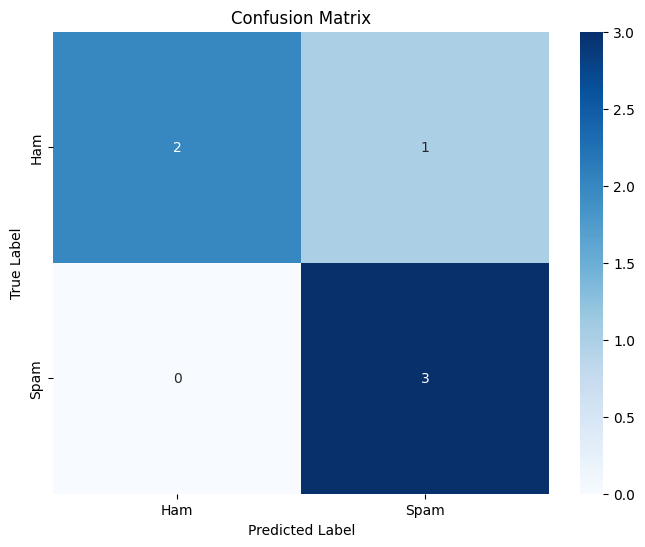

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define class labels for better readability
class_labels = ['Ham', 'Spam']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Evaluate what it predict on a unseen new example email text

In [214]:
new_email_text = "Congratulations! You've been selected for a free gift. Click here to claim."

# Preprocess the new email text using the same function as before
processed_new_email = preprocess_text(new_email_text)

# Vectorize the processed new email text using the *fitted* TF-IDF vectorizer
X_new = tfidf_vectorizer.transform([processed_new_email])

# Predict the label using the trained model
prediction = model.predict(X_new)

# Convert numerical prediction back to original labels
predicted_label = ''
if prediction[0] == 1:
  predicted_label = 'Spam'
else:
  predicted_label = 'Ham'

print(f"Email Text:'{new_email_text}'")
print(f"Predicted Label: {predicted_label}")

Email Text:'Congratulations! You've been selected for a free gift. Click here to claim.'
Predicted Label: Spam
